📂 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔧 Configuration Locked.
   Input:       /content/drive/MyDrive/NSIS merged dataset/LSD_2_ULTRA_Master.csv
   Checkpoints: /content/drive/MyDrive/NSIS_Phase2_Checkpoints
   Final Save:  /content/drive/MyDrive/NSIS_Phase2_Binary_Sentinel

📄 Loading LSD-2 (Binary)...
   ✅ Loaded 195250 rows.
📊 Splits: Train(156200) | Val(19525) | Test(19525)

🔠 Tokenizing...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
 

Map:   0%|          | 0/156200 [00:00<?, ? examples/s]

Map:   0%|          | 0/19525 [00:00<?, ? examples/s]

Map:   0%|          | 0/19525 [00:00<?, ? examples/s]


🤖 Initializing DeBERTa Sentinel...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1403451299.py:121: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.



🔍 Checking for existing checkpoints...
   ⚠️ Found checkpoint: /content/drive/MyDrive/NSIS_Phase2_Checkpoints/checkpoint-19526
   🔄 Resuming training from there...

🚀 STARTING PHASE 2 TRAINING...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
3,0.218600,0.258732,0.900333,0.919653,0.931655,0.907957
4,0.198700,0.274629,0.900538,0.920187,0.927814,0.912685


✅ Training Finished in 41.18 minutes.

📈 Generating Reports...


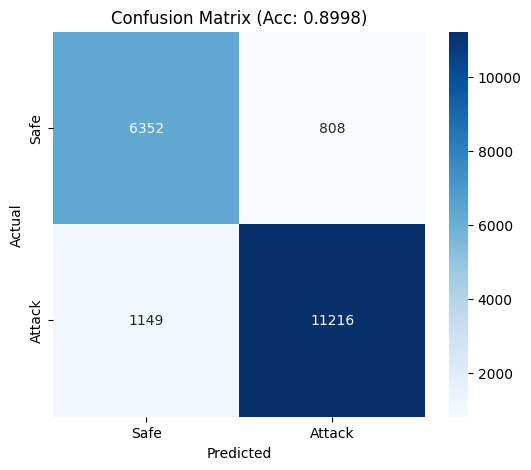

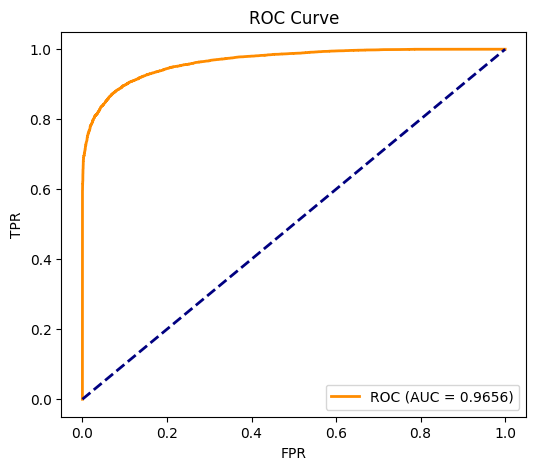


💾 Saving Final Model to Drive...
🎉 PHASE 2 COMPLETE.
   Final Model: /content/drive/MyDrive/NSIS_Phase2_Binary_Sentinel
   Checkpoints: /content/drive/MyDrive/NSIS_Phase2_Checkpoints


In [1]:
# @title Phase 2: Session-Proof Sentinel Training (Auto-Resume)
# @markdown This script saves checkpoints to Drive and automatically resumes if the session crashes.

# 1. INSTALL DEPENDENCIES
!pip install -q transformers datasets accelerate scikit-learn seaborn matplotlib

import pandas as pd
import numpy as np
import torch
import json
import time
import shutil
import os
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from transformers.trainer_utils import get_last_checkpoint
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# ==========================================
# 1. CONFIGURATION (Drive-Based)
# ==========================================
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

# --- PATHS ---
DATASET_PATH = "/content/drive/MyDrive/NSIS merged dataset/LSD_2_ULTRA_Master.csv"

# CHECKPOINT DIRECTORY (In Drive)
# This is where intermediate progress is saved (e.g., checkpoint-500)
DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/NSIS_Phase2_Checkpoints"

# FINAL MODEL DIRECTORY (In Drive)
# This is where the finished, best model goes
DRIVE_FINAL_MODEL_DIR = "/content/drive/MyDrive/NSIS_Phase2_Binary_Sentinel"

MODEL_CHECKPOINT = "microsoft/deberta-v3-small"
LOG_FILE = "phase2_logs.json"

# Ensure directories exist
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DRIVE_FINAL_MODEL_DIR, exist_ok=True)

print(f"🔧 Configuration Locked.")
print(f"   Input:       {DATASET_PATH}")
print(f"   Checkpoints: {DRIVE_CHECKPOINT_DIR}")
print(f"   Final Save:  {DRIVE_FINAL_MODEL_DIR}")

# ==========================================
# 2. DATA PREPARATION
# ==========================================
print("\n📄 Loading LSD-2 (Binary)...")
try:
    df = pd.read_csv(DATASET_PATH)
    df = df[['text', 'label']]
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"   ✅ Loaded {len(df)} rows.")
except Exception as e:
    print(f"❌ Error loading file: {e}")
    exit()

dataset = Dataset.from_pandas(df)
splits = dataset.train_test_split(test_size=0.2, seed=42)
test_valid = splits['test'].train_test_split(test_size=0.5, seed=42)

ds = DatasetDict({
    'train': splits['train'],
    'validation': test_valid['train'],
    'test': test_valid['test']
})

print(f"📊 Splits: Train({len(ds['train'])}) | Val({len(ds['validation'])}) | Test({len(ds['test'])})")

# Tokenization
print("\n🔠 Tokenizing...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def preprocess(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_ds = ds.map(preprocess, batched=True)

# ==========================================
# 3. METRICS & TRAINING
# ==========================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

print("\n🤖 Initializing DeBERTa Sentinel...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_CHECKPOINT, num_labels=2)

args = TrainingArguments(
    output_dir=DRIVE_CHECKPOINT_DIR,  # <--- SAVES DIRECTLY TO DRIVE
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,               # Keep only last 2 checkpoints (save Drive space)
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['validation'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# ==========================================
# 4. RESUME LOGIC (The Safety Net)
# ==========================================
print("\n🔍 Checking for existing checkpoints...")
last_checkpoint = get_last_checkpoint(DRIVE_CHECKPOINT_DIR)

if last_checkpoint:
    print(f"   ⚠️ Found checkpoint: {last_checkpoint}")
    print("   🔄 Resuming training from there...")
    resume_from_checkpoint = True
else:
    print("   🆕 No checkpoint found. Starting fresh.")
    resume_from_checkpoint = False

print("\n🚀 STARTING PHASE 2 TRAINING...")
start_time = time.time()

# Train (with resume logic)
train_result = trainer.train(resume_from_checkpoint=last_checkpoint)
training_time = time.time() - start_time
print(f"✅ Training Finished in {training_time/60:.2f} minutes.")

# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================
print("\n📈 Generating Reports...")
preds_output = trainer.predict(tokenized_ds['test'])
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=-1)
probs = torch.nn.functional.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()[:, 1]
metrics = preds_output.metrics

# --- A. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Safe', 'Attack'], yticklabels=['Safe', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Acc: {metrics["test_accuracy"]:.4f})')
plt.savefig("confusion_matrix.png")
plt.show()

# --- B. ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")
plt.show()

# --- C. Final Save ---
print("\n💾 Saving Final Model to Drive...")
# We save the BEST model to a clean folder, separating it from the temp checkpoints
trainer.save_model(DRIVE_FINAL_MODEL_DIR)

log_data = {
    "model": "DeBERTa-v3-Small (Binary)",
    "dataset": "LSD_2_ULTRA_Master.csv",
    "accuracy": metrics['test_accuracy'],
    "auc": roc_auc,
    "training_time": training_time
}
with open(LOG_FILE, "w") as f:
    json.dump(log_data, f, indent=4)

for f in ["confusion_matrix.png", "roc_curve.png", LOG_FILE]:
    shutil.copy(f, os.path.join(DRIVE_FINAL_MODEL_DIR, f))

print(f"🎉 PHASE 2 COMPLETE.")
print(f"   Final Model: {DRIVE_FINAL_MODEL_DIR}")
print(f"   Checkpoints: {DRIVE_CHECKPOINT_DIR}")